In [ ]:
# Data collection command:
# `python comet_download.py --project=ns-autostep-feature-search-results --n_threads=8`

In [1]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.feature_search.analysis.analysis_utils import *
from phd.feature_search.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

## Load Data

In [3]:
save_path = 'figures/'
config_data_path = 'data/ns-autostep-feature-search-results_params.csv'
run_data_path = 'data/ns-autostep-feature-search-results_metrics.csv'

config_dfs, run_dfs = load_experiment_data(config_data_path, run_data_path)
{k: len(v) for k, v in config_dfs.items()}

{'median_utility_reset': 30,
 'zero_utility_reset': 30,
 'perfect_features_baseline': 29}

## Comparison

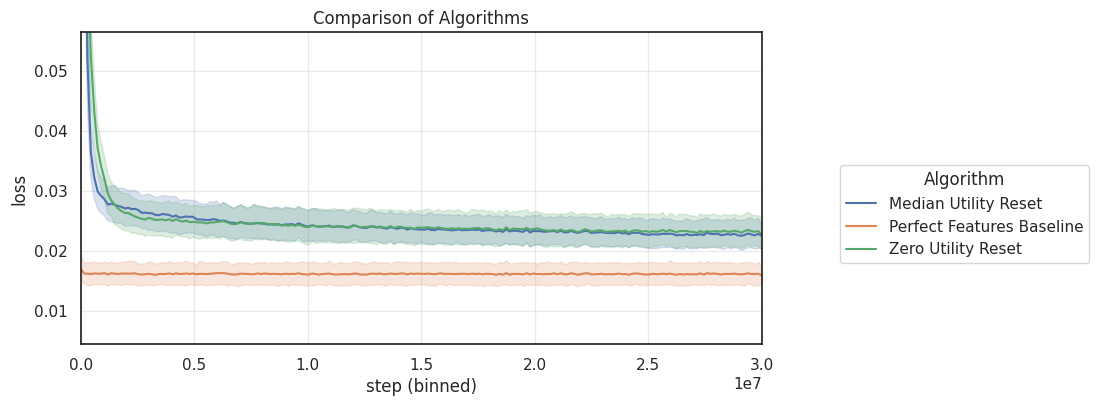

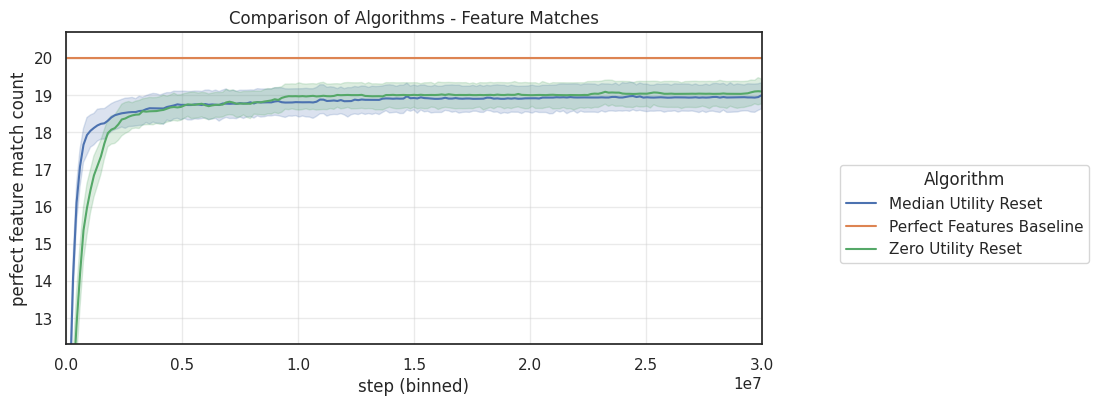

In [9]:
combined_run_df = pd.concat(list(run_dfs.values()))
combined_config_df = pd.concat(list(config_dfs.values()))

algo_map = {
    'median_utility_reset': 'Median Utility Reset',
    'zero_utility_reset': 'Zero Utility Reset',
    'perfect_features_baseline': 'Perfect Features Baseline'
}
combined_config_df['algo'] = combined_config_df['sweep_name'].map(algo_map)

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    hue_col = 'algo',
    legend_title = 'Algorithm',
    show_ci = True,
)
# plt.xlim(0, 1_500_000)
plt.title('Comparison of Algorithms')
plt.show()

plot_learning_curves(
    run_df = combined_run_df,
    config_df = combined_config_df,
    n_bins = 200,
    figsize = (8, 4),
    y_col = 'feature_match/perfect_match_count',
    y_label = 'perfect feature match count',
    hue_col = 'algo',
    legend_title = 'Algorithm',
    show_ci = True,
)
# plt.xlim(0, 1_500_000)
plt.title('Comparison of Algorithms - Feature Matches')
plt.show()